# 🤖 Notebook 3 — Modeling
**Project:** Smartphone Addiction Prediction  
**Goal:** Train, tune, compare multiple classifiers, pick the best, and save artifacts for deployment.

---

## 1. Imports & Configuration

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
from pathlib import Path

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

# Tuning & Evaluation
from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    RocCurveDisplay, PrecisionRecallDisplay
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

OUTPUT_DIR = Path('../outputs')
MODEL_DIR  = Path('../models')
MODEL_DIR.mkdir(exist_ok=True)

RANDOM_STATE = 42

## 2. Load Preprocessed Data

In [16]:
X_train = pd.read_csv(OUTPUT_DIR / 'X_train.csv')
y_train = pd.read_csv(OUTPUT_DIR / 'y_train.csv').squeeze()
X_val   = pd.read_csv(OUTPUT_DIR / 'X_val.csv')
y_val   = pd.read_csv(OUTPUT_DIR / 'y_val.csv').squeeze()
X_test  = pd.read_csv(OUTPUT_DIR / 'X_test.csv')
y_test  = pd.read_csv(OUTPUT_DIR / 'y_test.csv').squeeze()

print(f'Train: {X_train.shape}  Val: {X_val.shape}  Test: {X_test.shape}')
print(f'Train target distribution:\n{y_train.value_counts()}')

Train: (7432, 12)  Val: (1125, 12)  Test: (1125, 12)
Train target distribution:
addicted_label
0    3716
1    3716
Name: count, dtype: int64


## 3. Helper — Evaluation Function

In [17]:
def evaluate_model(model, X, y, dataset_name='Validation'):
    """Return a dict of common classification metrics."""
    y_pred = model.predict(X)
    y_prob = model.predict_proba(X)[:, 1] if hasattr(model, 'predict_proba') else None

    metrics = {
        'Accuracy':  accuracy_score(y, y_pred),
        'Precision': precision_score(y, y_pred, zero_division=0),
        'Recall':    recall_score(y, y_pred, zero_division=0),
        'F1':        f1_score(y, y_pred, zero_division=0),
        'ROC-AUC':   roc_auc_score(y, y_prob) if y_prob is not None else np.nan,
    }
    print(f'\n=== {dataset_name} Metrics ===')
    for k, v in metrics.items():
        print(f'  {k:<12}: {v:.4f}')
    return metrics


def plot_confusion_matrix(model, X, y, title, ax=None):
    """Plot a confusion matrix on a given axes."""
    y_pred = model.predict(X)
    cm = confusion_matrix(y, y_pred)
    if ax is None:
        _, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Not Addicted', 'Addicted'],
                yticklabels=['Not Addicted', 'Addicted'], ax=ax)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(title, fontsize=11, fontweight='bold')
    return ax

## 4. Baseline Models (5-Fold Cross Validation)

In [18]:
baseline_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'Decision Tree':       DecisionTreeClassifier(random_state=RANDOM_STATE),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
    'Gradient Boosting':   GradientBoostingClassifier(random_state=RANDOM_STATE),
    'XGBoost':             XGBClassifier(eval_metric='logloss', random_state=RANDOM_STATE, verbosity=0),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'SVM':                 SVC(probability=True, random_state=RANDOM_STATE),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_results = {}

for name, model in baseline_models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv,
                             scoring='f1', n_jobs=-1)
    cv_results[name] = {'mean_f1': scores.mean(), 'std_f1': scores.std()}
    print(f'{name:<25}  F1 = {scores.mean():.4f} ± {scores.std():.4f}')

cv_df = pd.DataFrame(cv_results).T.sort_values('mean_f1', ascending=False)
cv_df

Logistic Regression        F1 = 0.8776 ± 0.0098
Decision Tree              F1 = 0.9449 ± 0.0072
Random Forest              F1 = 0.9554 ± 0.0044
Gradient Boosting          F1 = 0.9521 ± 0.0045
XGBoost                    F1 = 0.9580 ± 0.0042
K-Nearest Neighbors        F1 = 0.8837 ± 0.0131
SVM                        F1 = 0.9399 ± 0.0041


,mean_f1,std_f1
XGBoost,0.957970,0.004237
Random Forest,0.955419,0.004439
Gradient Boosting,0.952055,0.004469
Decision Tree,0.944941,0.007200
SVM,0.939905,0.004098
K-Nearest Neighbors,0.883694,0.013112
Logistic Regression,0.877602,0.009789


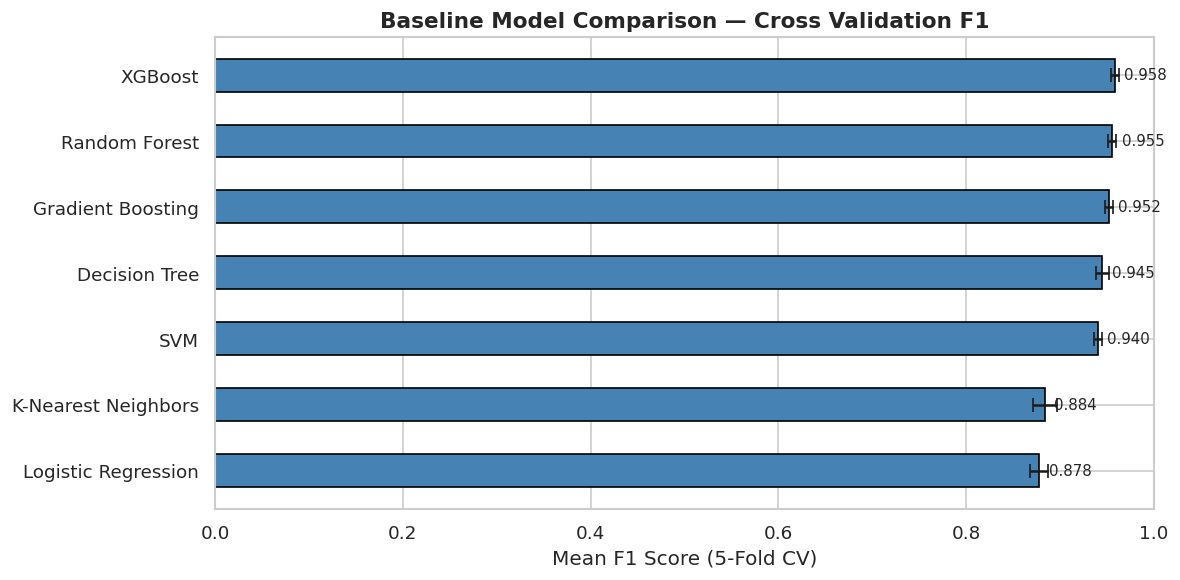

In [19]:
# Visualize cross-validation comparison
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(cv_df.index[::-1], cv_df['mean_f1'][::-1],
               xerr=cv_df['std_f1'][::-1], color='steelblue',
               edgecolor='black', height=0.5, capsize=4)
ax.set_xlabel('Mean F1 Score (5-Fold CV)')
ax.set_title('Baseline Model Comparison — Cross Validation F1', fontsize=13, fontweight='bold')
ax.set_xlim(0, 1)
for bar in bars:
    w = bar.get_width()
    ax.text(w + 0.01, bar.get_y() + bar.get_height()/2,
            f'{w:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '03_baseline_comparison.png', bbox_inches='tight')
plt.show()

## 5. Hyperparameter Tuning — Top 2 Models

In [20]:
rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'class_weight': [None, 'balanced'],
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE),
    rf_param_grid, cv=cv, scoring='f1', n_jobs=-1, verbose=1
)
rf_grid.fit(X_train, y_train)
print(f'\nBest RF Params: {rf_grid.best_params_}')
print(f'Best RF CV F1:  {rf_grid.best_score_:.4f}')

Fitting 5 folds for each of 24 candidates, totalling 120 fits

Best RF Params: {'class_weight': None, 'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}
Best RF CV F1:  0.9560


In [21]:
xgb_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample': [0.8, 1.0],
}

xgb_grid = GridSearchCV(
    XGBClassifier(eval_metric='logloss', random_state=RANDOM_STATE, verbosity=0),
    xgb_param_grid, cv=cv, scoring='f1', n_jobs=-1, verbose=1
)
xgb_grid.fit(X_train, y_train)
print(f'\nBest XGB Params: {xgb_grid.best_params_}')
print(f'Best XGB CV F1:  {xgb_grid.best_score_:.4f}')

Fitting 5 folds for each of 36 candidates, totalling 180 fits

Best XGB Params: {'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 200, 'subsample': 1.0}
Best XGB CV F1:  0.9575


## 6. Evaluate Tuned Models on Validation Set

In [22]:
tuned_models = {
    'Random Forest (tuned)': rf_grid.best_estimator_,
    'XGBoost (tuned)':       xgb_grid.best_estimator_,
}

val_results = {}
for name, model in tuned_models.items():
    metrics = evaluate_model(model, X_val, y_val, dataset_name=name)
    val_results[name] = metrics

val_df = pd.DataFrame(val_results).T
print('\n=== Validation Comparison ===')
val_df


=== Random Forest (tuned) Metrics ===
  Accuracy    : 0.9413
  Precision   : 0.9867
  Recall      : 0.9296
  F1          : 0.9573
  ROC-AUC     : 0.9891

=== XGBoost (tuned) Metrics ===
  Accuracy    : 0.9333
  Precision   : 0.9725
  Recall      : 0.9322
  F1          : 0.9519
  ROC-AUC     : 0.9883

=== Validation Comparison ===


,Accuracy,Precision,Recall,F1,ROC-AUC
Random Forest (tuned),0.941333,0.986667,0.929648,0.957309,0.989129
XGBoost (tuned),0.933333,0.972477,0.932161,0.951892,0.988285


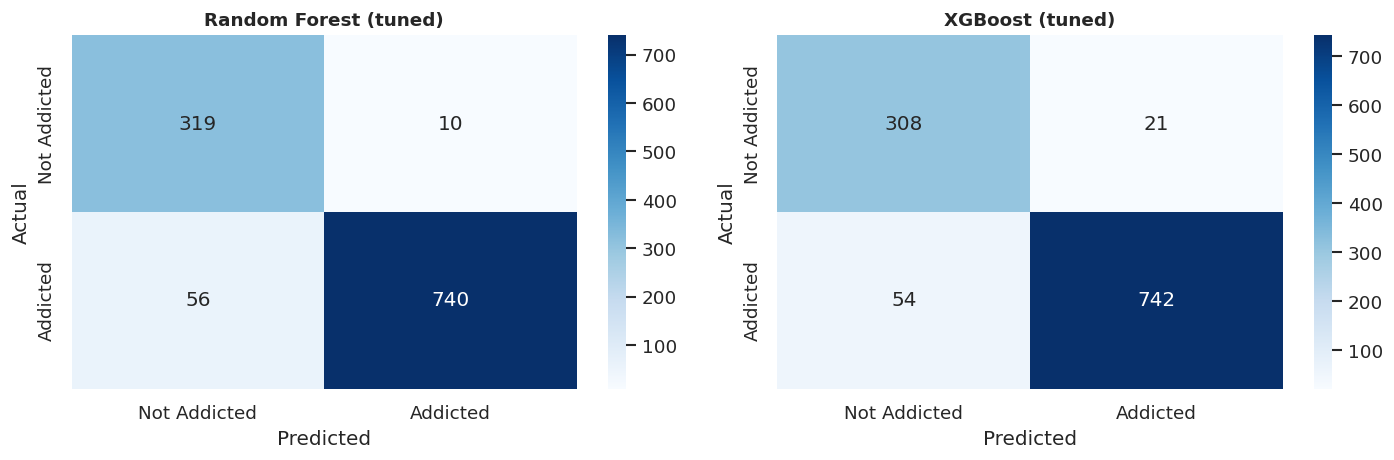

In [23]:
# Confusion matrices side-by-side
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (name, model) in zip(axes, tuned_models.items()):
    plot_confusion_matrix(model, X_val, y_val, title=name, ax=ax)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '03_confusion_matrices.png', bbox_inches='tight')
plt.show()

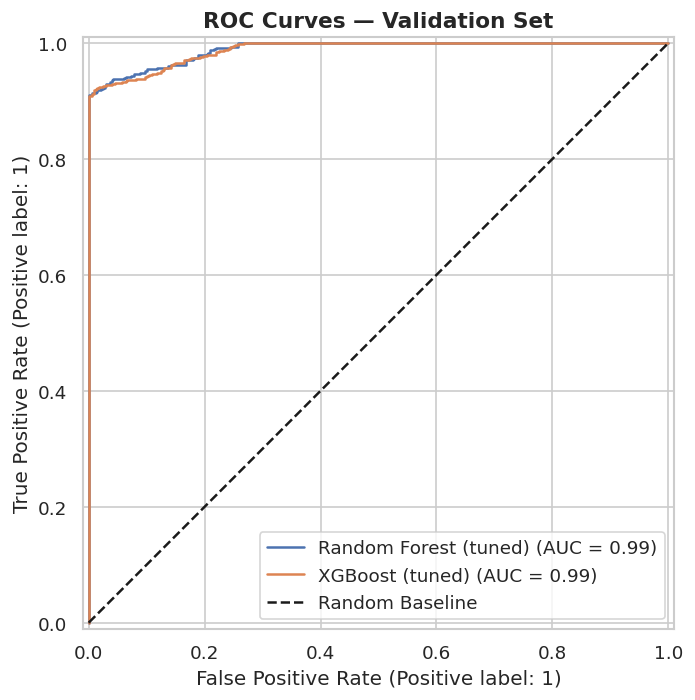

In [24]:
# ROC curves
fig, ax = plt.subplots(figsize=(8, 6))
for name, model in tuned_models.items():
    RocCurveDisplay.from_estimator(model, X_val, y_val, ax=ax, name=name)
ax.set_title('ROC Curves — Validation Set', fontsize=13, fontweight='bold')
ax.plot([0, 1], [0, 1], 'k--', label='Random Baseline')
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '03_roc_curves.png', bbox_inches='tight')
plt.show()

## 7. Select Best Model & Final Test Evaluation

In [25]:
# Pick the model with the highest validation F1
best_name = val_df['F1'].idxmax()
best_model = tuned_models[best_name]
print(f'\n🏆 Best Model: {best_name}')

# --- Final evaluation on held-out TEST set ---
test_metrics = evaluate_model(best_model, X_test, y_test, dataset_name='TEST SET (final)')
print('\n--- Classification Report ---')
print(classification_report(y_test, best_model.predict(X_test),
                             target_names=['Not Addicted', 'Addicted']))


🏆 Best Model: Random Forest (tuned)

=== TEST SET (final) Metrics ===
  Accuracy    : 0.9351
  Precision   : 0.9788
  Recall      : 0.9284
  F1          : 0.9529
  ROC-AUC     : 0.9892

--- Classification Report ---
              precision    recall  f1-score   support

Not Addicted       0.85      0.95      0.90       329
    Addicted       0.98      0.93      0.95       796

    accuracy                           0.94      1125
   macro avg       0.91      0.94      0.92      1125
weighted avg       0.94      0.94      0.94      1125



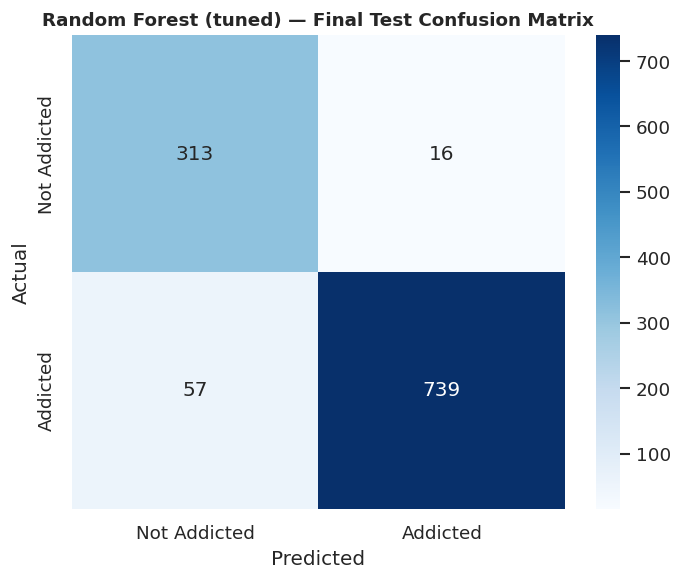

In [26]:
# Final confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
plot_confusion_matrix(best_model, X_test, y_test,
                      title=f'{best_name} — Final Test Confusion Matrix', ax=ax)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '03_final_confusion_matrix.png', bbox_inches='tight')
plt.show()

## 8. Feature Importance

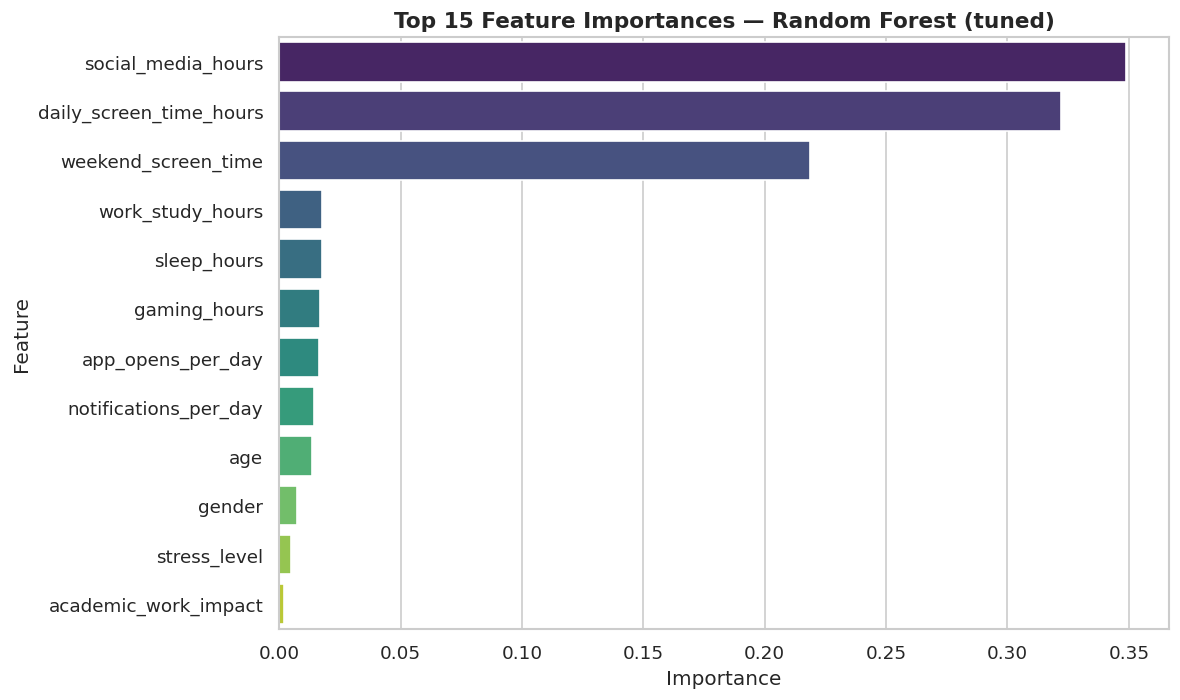

In [27]:
if hasattr(best_model, 'feature_importances_'):
    feature_names = joblib.load(OUTPUT_DIR / 'feature_names.pkl')
    fi_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False).head(15)

    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance', y='Feature', data=fi_df, palette='viridis')
    plt.title(f'Top 15 Feature Importances — {best_name}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / '03_feature_importance.png', bbox_inches='tight')
    plt.show()
else:
    print('Feature importances not available for this model type.')

## 9. Save Best Model

In [28]:
joblib.dump(best_model, MODEL_DIR / 'best_model.pkl')
print(f'✅ Best model saved → models/best_model.pkl')

# Save experiment summary
summary = pd.concat([val_df, pd.DataFrame(test_metrics, index=['TEST']).rename_axis('Model')])
summary.to_csv(OUTPUT_DIR / 'model_comparison.csv')
print('✅ Model comparison saved → outputs/model_comparison.csv')

✅ Best model saved → models/best_model.pkl
✅ Model comparison saved → outputs/model_comparison.csv


## 10. Modeling Summary

| Step | Action |
|------|--------|
| Baseline | 7 classifiers compared with 5-fold CV (F1) |
| Tuning | GridSearchCV on Random Forest & XGBoost |
| Best model | *Filled after run* |
| Test Accuracy | *Filled after run* |
| Test F1 | *Filled after run* |
| Test ROC-AUC | *Filled after run* |